# OpInf KS Regularization Grid Search & Threshold Analysis

This notebook loads pre-computed step 1 outputs (learning matrices, gamma reference, ICs)
from an existing OpInf KS run, then:

1. Sweeps a dense grid of regularization parameters (state & output)
2. Records per-combo error metrics (mean/std error for energy & enstrophy)
3. Visualises error distributions and parameter sensitivities
4. Sweeps threshold pairs (threshold_mean, threshold_std) to show how many models pass
5. Picks the 10 best models by several criteria and plots their forecasts

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
from pathlib import Path

# Repo root
REPO_ROOT = Path(os.path.abspath("")).parent
sys.path.insert(0, str(REPO_ROOT / "opinf"))
sys.path.insert(0, str(REPO_ROOT))

from core import get_quadratic_terms, solve_difference_model

print(f"Repo root: {REPO_ROOT}")

Repo root: /home/anthonypoole/repos/not_work/IEEE


## Configuration

Point `RUN_DIR` at an existing step-1 output that already has `learning_matrices.npz`,
`gamma_reference.npz`, `initial_conditions.npz`, and `data_boundaries.npz`.

In [2]:
# === Point this at your step-1 run directory ===
RUN_DIR = REPO_ROOT / "local_output" / "20260223_105901_opinf_ks_temporal_split"

# === KS data file (for reference QoI on the test window) ===
KS_DATA_FILE = REPO_ROOT / "data" / "ks" / "ks_sim_step0.1_L100_N200_steps2000_20260223093716_4479.h5"

# === Temporal split ranges (must match config used for step 1) ===
TRAIN_START = 1250
TRAIN_END   = 1750
TEST_START  = 1750
TEST_END    = 2000

N_TRAIN = TRAIN_END - TRAIN_START   # 500
N_TEST  = TEST_END - TEST_START     # 250

print(f"Run dir exists: {RUN_DIR.is_dir()}")
print(f"Train window: [{TRAIN_START}, {TRAIN_END})  ({N_TRAIN} steps)")
print(f"Test  window: [{TEST_START}, {TEST_END})  ({N_TEST} steps)")

Run dir exists: True
Train window: [1250, 1750)  (500 steps)
Test  window: [1750, 2000)  (250 steps)


## 1. Load Pre-computed Data

In [3]:
# Learning matrices from step 1
lm = np.load(RUN_DIR / "learning_matrices.npz")
X_state   = lm["X_state"]
Y_state   = lm["Y_state"]
D_state   = lm["D_state"]
D_state_2 = lm["D_state_2"]
D_out     = lm["D_out"]
D_out_2   = lm["D_out_2"]
mean_Xhat = lm["mean_Xhat"]
scaling_Xhat = float(lm["scaling_Xhat"])

# Gamma / QoI reference (energy, enstrophy for KS)
gr = np.load(RUN_DIR / "gamma_reference.npz")
Y_Gamma      = gr["Y_Gamma"]          # (2, n_train)
mean_Gamma_n = float(gr["mean_Gamma_n"])  # mean energy
std_Gamma_n  = float(gr["std_Gamma_n"])
mean_Gamma_c = float(gr["mean_Gamma_c"])  # mean enstrophy
std_Gamma_c  = float(gr["std_Gamma_c"])

# Initial conditions
ic = np.load(RUN_DIR / "initial_conditions.npz")
train_IC = ic["train_ICs_reduced"][0]  # (r,)
test_IC  = ic["test_ICs_reduced"][0]   # (r,)

# Boundaries
bd = np.load(RUN_DIR / "data_boundaries.npz")
train_boundaries = bd["train_boundaries"]
test_boundaries  = bd["test_boundaries"]

# Xhat (reduced coordinates) for test reference
Xhat_test = np.load(RUN_DIR / "X_hat_test.npy")   # (n_test, r)

r = X_state.shape[1]
s = r * (r + 1) // 2

print(f"POD rank r = {r}")
print(f"Quadratic terms s = {s}")
print(f"X_state: {X_state.shape}, D_state: {D_state.shape}")
print(f"D_out:   {D_out.shape}")
print(f"Y_Gamma: {Y_Gamma.shape}")
print(f"Ref QoI — energy:    mean={mean_Gamma_n:.4f}, std={std_Gamma_n:.4f}")
print(f"Ref QoI — enstrophy: mean={mean_Gamma_c:.4f}, std={std_Gamma_c:.4f}")

POD rank r = 9
Quadratic terms s = 45
X_state: (499, 9), D_state: (499, 54)
D_out:   (500, 55)
Y_Gamma: (2, 500)
Ref QoI — energy:    mean=0.8472, std=0.1106
Ref QoI — enstrophy: mean=1.0073, std=0.1727


## 2. Load Full Reference Data (Train + Test) for Plotting

In [4]:
import h5py

with h5py.File(KS_DATA_FILE, "r") as f:
    energy_full    = np.array(f["energy"][:])
    enstrophy_full = np.array(f["enstrophy"][:])
    u_full         = np.array(f["u"][:])         # (n_time, N)

ref_energy_train    = energy_full[TRAIN_START:TRAIN_END]
ref_enstrophy_train = enstrophy_full[TRAIN_START:TRAIN_END]
ref_energy_test     = energy_full[TEST_START:TEST_END]
ref_enstrophy_test  = enstrophy_full[TEST_START:TEST_END]

print(f"Reference train energy:    {ref_energy_train.shape}")
print(f"Reference test  energy:    {ref_energy_test.shape}")

Reference train energy:    (500,)
Reference test  energy:    (250,)


## 3. Define Regularization Grid

In [5]:
# --- State operator regularisation ---
state_lin_vals  = np.logspace(-10, 10, 30)
state_quad_vals = np.logspace(-10, 10, 30)

# --- Output operator regularisation ---
out_lin_vals  = np.logspace(-10, 10, 30)
out_quad_vals = np.logspace(-10, 10, 30)

n_state_combos  = len(state_lin_vals) * len(state_quad_vals)
n_output_combos = len(out_lin_vals) * len(out_quad_vals)
n_total = n_state_combos * n_output_combos

print(f"State reg combos:  {n_state_combos:,}")
print(f"Output reg combos: {n_output_combos:,}")
print(f"Total combos:      {n_total:,}")
print()
print("NOTE: The sweep below decouples state & output operators.")
print("First we find stable state operators, then grid-search output")
print("operators only for the stable ones. This is MUCH faster.")

State reg combos:  900
Output reg combos: 900
Total combos:      810,000

NOTE: The sweep below decouples state & output operators.
First we find stable state operators, then grid-search output
operators only for the stable ones. This is MUCH faster.


## 4. Phase 1 — State Operator Sweep

For each `(alpha_state_lin, alpha_state_quad)` pair we:
1. Solve the state operator least-squares problem
2. Integrate forward from the training IC for `N_TRAIN` steps
3. Record whether it blew up (NaN/Inf), and if not, the state-space relative error

In [6]:
d_state = r + s

state_results = []
n_nan = 0

for asl, asq in product(state_lin_vals, state_quad_vals):
    # Build regularisation vector
    reg = np.zeros(d_state)
    reg[:r] = asl
    reg[r:] = asq

    # Solve normal equations
    DtD = D_state_2 + np.diag(reg)
    O = np.linalg.solve(DtD, D_state.T @ Y_state).T
    A, F = O[:, :r], O[:, r:]

    # Integrate on TRAINING window
    f_rom = lambda x, A=A, F=F: A @ x + F @ get_quadratic_terms(x)
    is_nan, Xhat_pred = solve_difference_model(train_IC, N_TRAIN, f_rom)

    if is_nan:
        n_nan += 1
        continue

    # Relative state-space error on train window
    Xhat_train_ref = X_state  # (n_train-1, r) — but Xhat_pred is (r, N_TRAIN)
    pred_T = Xhat_pred.T      # (N_TRAIN, r)
    # Align lengths (X_state has N_TRAIN-1 pairs, pred has N_TRAIN points)
    n_compare = min(pred_T.shape[0], X_state.shape[0])
    rel_state_err = np.linalg.norm(pred_T[:n_compare] - X_state[:n_compare]) / (
        np.linalg.norm(X_state[:n_compare]) + 1e-30
    )

    state_results.append({
        "asl": asl, "asq": asq,
        "rel_state_err": rel_state_err,
        "A": A, "F": F,
        "Xhat_pred": Xhat_pred,  # (r, N_TRAIN)
    })

print(f"State sweep done: {len(state_results)} stable / {n_state_combos} total ({n_nan} NaN)")

/home/anthonypoole/repos/not_work/IEEE/opinf/core.py:38: RuntimeWarning: overflow encountered in multiply
  prods = [X[i] * X[i:] for i in range(r)]
/tmp/ipykernel_5172/151214144.py:18: RuntimeWarning: invalid value encountered in matmul
  f_rom = lambda x, A=A, F=F: A @ x + F @ get_quadratic_terms(x)


State sweep done: 417 stable / 900 total (483 NaN)


## 5. Phase 2 — Output Operator Sweep (on stable state operators)

For each stable state operator *and* each `(alpha_out_lin, alpha_out_quad)` pair,
solve the output least-squares and compute QoI error metrics on the **training** window.

In [7]:
d_out = r + s + 1  # linear + quad + constant

full_results = []  # list of dicts

for si, sr in enumerate(state_results):
    Xhat_pred = sr["Xhat_pred"]  # (r, N_TRAIN)
    X_OpInf = Xhat_pred.T         # (N_TRAIN, r)

    # Scale for output learning (same transform as step 1)
    Xhat_scaled = (X_OpInf - mean_Xhat) / scaling_Xhat
    Xhat_2 = get_quadratic_terms(Xhat_scaled)

    for aol, aoq in product(out_lin_vals, out_quad_vals):
        reg_out = np.zeros(d_out)
        reg_out[:r]     = aol
        reg_out[r:r+s]  = aoq
        reg_out[r+s:]   = aol

        DtD_out = D_out_2 + np.diag(reg_out)
        O_out = np.linalg.solve(DtD_out, D_out.T @ Y_Gamma.T).T
        C, G, c_vec = O_out[:, :r], O_out[:, r:r+s], O_out[:, r+s]

        # Predict QoI on training window
        Y_pred = C @ Xhat_scaled.T + G @ Xhat_2.T + c_vec[:, np.newaxis]
        pred_energy    = Y_pred[0, :]
        pred_enstrophy = Y_pred[1, :]

        # Relative errors in statistics
        mean_err_n = abs(mean_Gamma_n - np.mean(pred_energy))    / (abs(mean_Gamma_n) + 1e-30)
        std_err_n  = abs(std_Gamma_n  - np.std(pred_energy, ddof=1)) / (std_Gamma_n  + 1e-30)
        mean_err_c = abs(mean_Gamma_c - np.mean(pred_enstrophy)) / (abs(mean_Gamma_c) + 1e-30)
        std_err_c  = abs(std_Gamma_c  - np.std(pred_enstrophy, ddof=1)) / (std_Gamma_c  + 1e-30)
        total_error = mean_err_n + std_err_n + mean_err_c + std_err_c

        full_results.append({
            "asl": sr["asl"], "asq": sr["asq"],
            "aol": aol, "aoq": aoq,
            "rel_state_err":  sr["rel_state_err"],
            "mean_err_energy":    mean_err_n,
            "std_err_energy":     std_err_n,
            "mean_err_enstrophy": mean_err_c,
            "std_err_enstrophy":  std_err_c,
            "total_error":        total_error,
            # Store operators for later replay
            "A": sr["A"], "F": sr["F"],
            "C": C, "G": G, "c": c_vec,
        })

    # Progress
    if (si + 1) % 50 == 0 or si == len(state_results) - 1:
        print(f"  Processed {si+1}/{len(state_results)} stable state operators "
              f"({len(full_results):,} full combos so far)")

print(f"\nFull sweep done: {len(full_results):,} valid combos")

  Processed 50/417 stable state operators (45,000 full combos so far)
  Processed 100/417 stable state operators (90,000 full combos so far)
  Processed 150/417 stable state operators (135,000 full combos so far)
  Processed 200/417 stable state operators (180,000 full combos so far)
  Processed 250/417 stable state operators (225,000 full combos so far)
  Processed 300/417 stable state operators (270,000 full combos so far)
  Processed 350/417 stable state operators (315,000 full combos so far)
  Processed 400/417 stable state operators (360,000 full combos so far)
  Processed 417/417 stable state operators (375,300 full combos so far)

Full sweep done: 375,300 valid combos


## 6. Error Distribution Overview

In [8]:
# Extract arrays for analysis
total_errors     = np.array([r["total_error"] for r in full_results])
mean_errs_energy = np.array([r["mean_err_energy"] for r in full_results])
std_errs_energy  = np.array([r["std_err_energy"] for r in full_results])
mean_errs_enstr  = np.array([r["mean_err_enstrophy"] for r in full_results])
std_errs_enstr   = np.array([r["std_err_enstrophy"] for r in full_results])
state_errs       = np.array([r["rel_state_err"] for r in full_results])

print("Error statistics across all valid combos:")
for name, arr in [
    ("total_error", total_errors),
    ("mean_err_energy", mean_errs_energy),
    ("std_err_energy", std_errs_energy),
    ("mean_err_enstrophy", mean_errs_enstr),
    ("std_err_enstrophy", std_errs_enstr),
    ("rel_state_err", state_errs),
]:
    p10, p50, p90 = np.percentile(arr, [10, 50, 90])
    print(f"  {name:25s}: min={arr.min():.4e}  P10={p10:.4e}  "
          f"P50={p50:.4e}  P90={p90:.4e}  max={arr.max():.4e}")

Error statistics across all valid combos:
  total_error              : min=1.4647e-02  P10=4.0626e-01  P50=2.6528e+00  P90=6.2148e+00  max=2.8128e+17
  mean_err_energy          : min=1.1941e-05  P10=2.8875e-02  P50=3.2548e-01  P90=9.9666e-01  max=6.0266e+14
  std_err_energy           : min=2.6009e-05  P10=1.4781e-01  P50=8.1899e-01  P90=1.0348e+00  max=1.0325e+17
  mean_err_enstrophy       : min=2.6619e-06  P10=3.0827e-02  P50=4.1416e-01  P90=1.4099e+00  max=1.3503e+15
  std_err_enstrophy        : min=2.4128e-05  P10=1.0693e-01  P50=8.6500e-01  P90=4.3166e+00  max=1.7607e+17
  rel_state_err            : min=7.0095e-02  P10=3.5739e-01  P50=9.8841e-01  P90=9.9903e-01  max=4.9804e+03


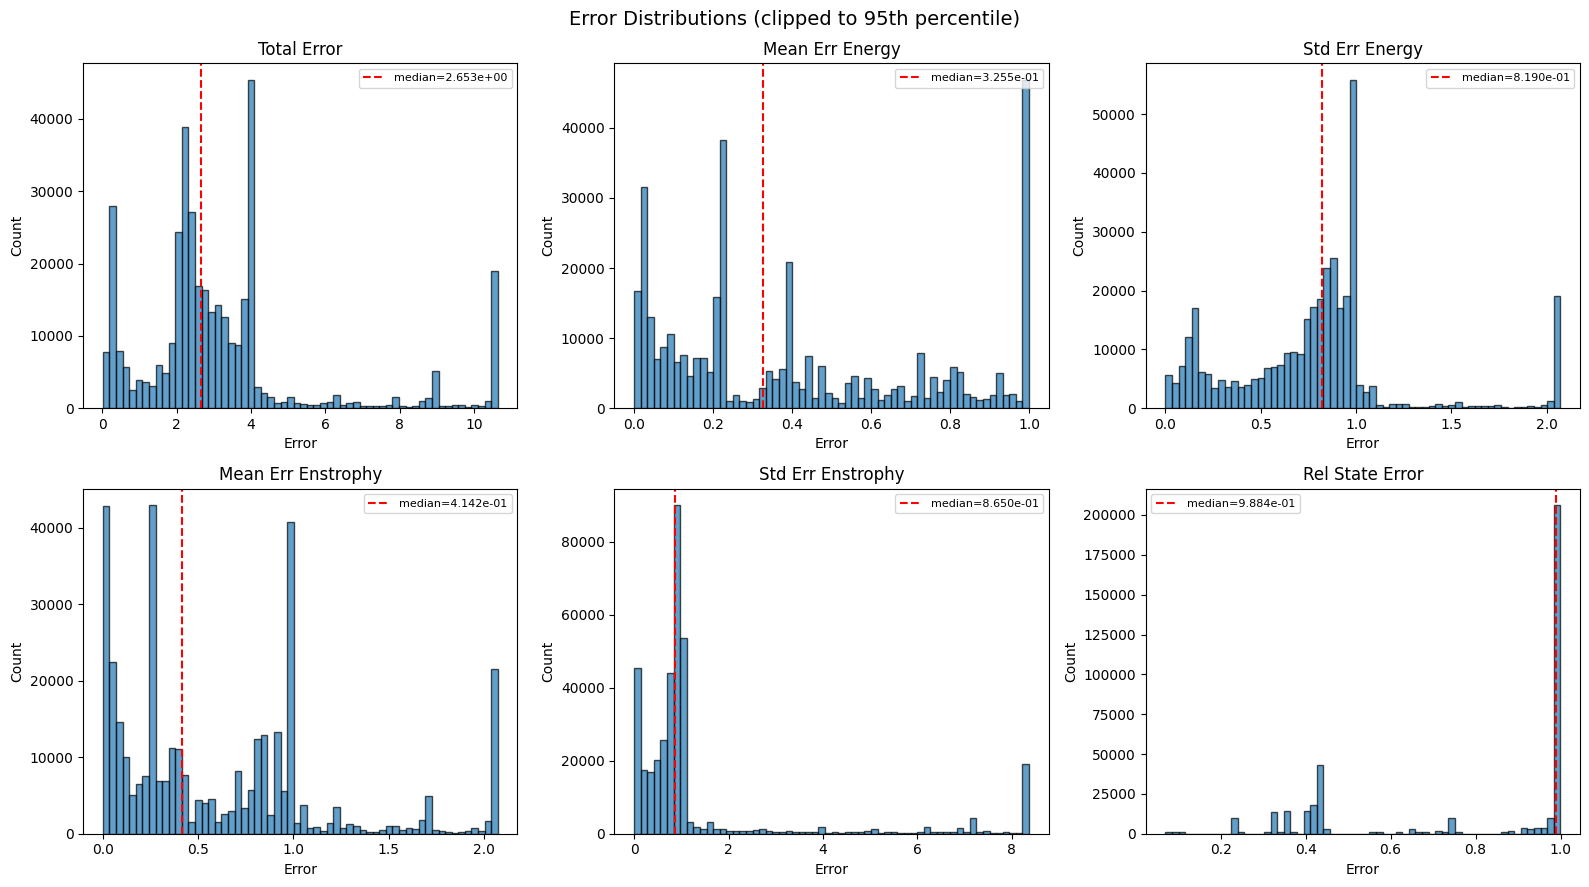

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

data_to_plot = [
    ("Total Error", total_errors),
    ("Mean Err Energy", mean_errs_energy),
    ("Std Err Energy", std_errs_energy),
    ("Mean Err Enstrophy", mean_errs_enstr),
    ("Std Err Enstrophy", std_errs_enstr),
    ("Rel State Error", state_errs),
]

for ax, (title, arr) in zip(axes.flat, data_to_plot):
    # Clip to reasonable range for visualisation
    clipped = np.clip(arr, 0, np.percentile(arr, 95))
    ax.hist(clipped, bins=60, edgecolor="k", alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel("Error")
    ax.set_ylabel("Count")
    ax.axvline(np.median(arr), color="r", ls="--", label=f"median={np.median(arr):.3e}")
    ax.legend(fontsize=8)

fig.suptitle("Error Distributions (clipped to 95th percentile)", fontsize=14)
plt.tight_layout()
plt.show()

## 7. Regularization Parameter Sensitivity

Best total error achieved for each state-reg pair (marginalised over output reg).

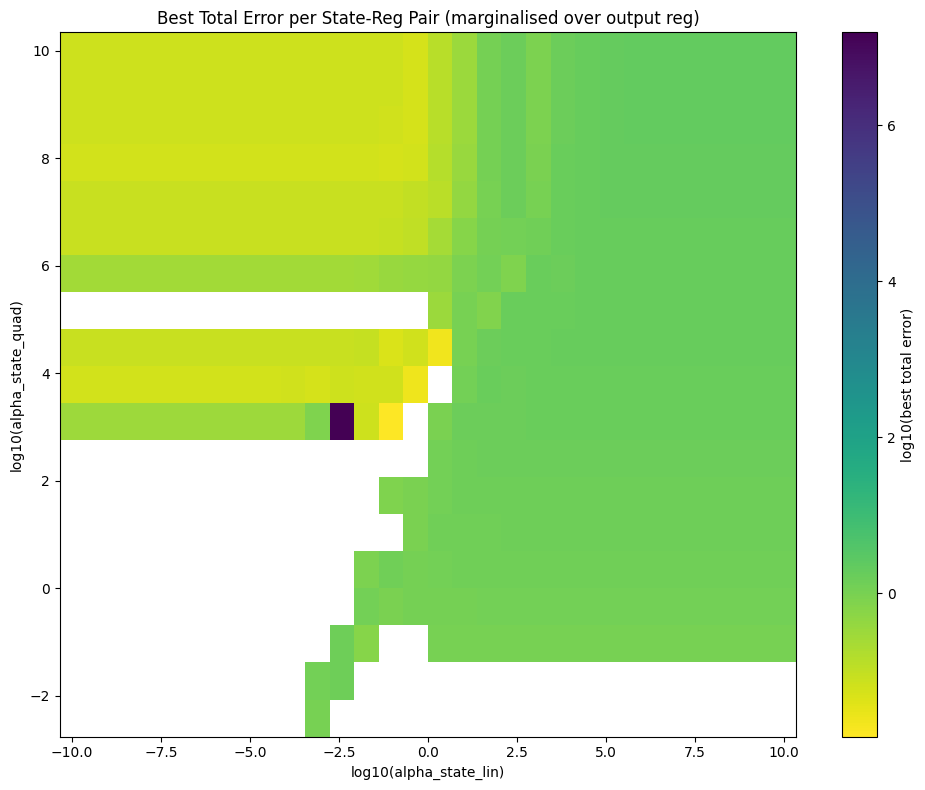

In [10]:
import pandas as pd

df = pd.DataFrame(full_results)
# Drop the numpy arrays for lighter handling
df_light = df.drop(columns=["A", "F", "C", "G", "c"], errors="ignore")

# Best total error per (asl, asq) — marginalise over output reg
best_per_state = df_light.groupby(["asl", "asq"])["total_error"].min().reset_index()
pivot_state = best_per_state.pivot(index="asq", columns="asl", values="total_error")

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.pcolormesh(
    np.log10(pivot_state.columns.values.astype(float)),
    np.log10(pivot_state.index.values.astype(float)),
    np.log10(np.clip(pivot_state.values, 1e-10, None)),
    cmap="viridis_r", shading="auto",
)
cb = plt.colorbar(im, ax=ax)
cb.set_label("log10(best total error)")
ax.set_xlabel("log10(alpha_state_lin)")
ax.set_ylabel("log10(alpha_state_quad)")
ax.set_title("Best Total Error per State-Reg Pair (marginalised over output reg)")
plt.tight_layout()
plt.show()

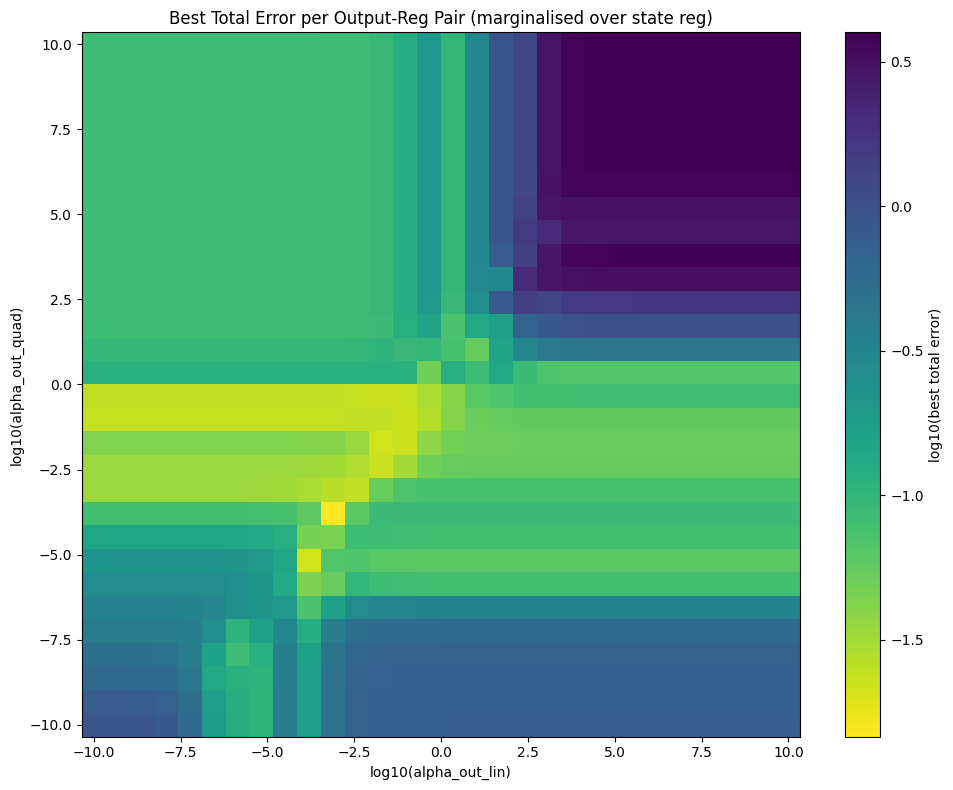

In [11]:
# Best total error per (aol, aoq) — marginalise over state reg
best_per_out = df_light.groupby(["aol", "aoq"])["total_error"].min().reset_index()
pivot_out = best_per_out.pivot(index="aoq", columns="aol", values="total_error")

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.pcolormesh(
    np.log10(pivot_out.columns.values.astype(float)),
    np.log10(pivot_out.index.values.astype(float)),
    np.log10(np.clip(pivot_out.values, 1e-10, None)),
    cmap="viridis_r", shading="auto",
)
cb = plt.colorbar(im, ax=ax)
cb.set_label("log10(best total error)")
ax.set_xlabel("log10(alpha_out_lin)")
ax.set_ylabel("log10(alpha_out_quad)")
ax.set_title("Best Total Error per Output-Reg Pair (marginalised over state reg)")
plt.tight_layout()
plt.show()

## 8. Threshold Grid Search

Sweep `(threshold_mean, threshold_std)` and report how many models pass each pair.
This helps pick thresholds that give a reasonable ensemble size.

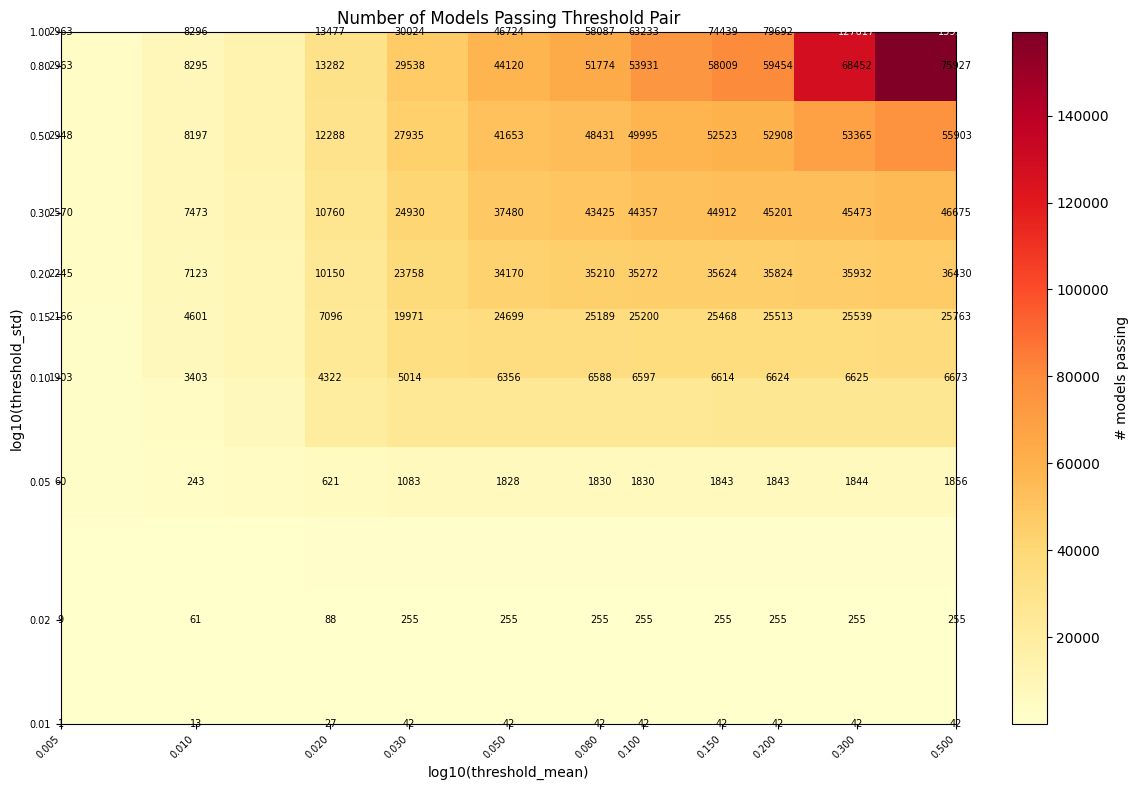


Passcount table (rows=thresh_std, cols=thresh_mean):
      0.005  0.010  0.020  0.030  0.050  0.080  0.100  0.150  0.200   0.300  \
0.01      1     13     27     42     42     42     42     42     42      42   
0.02      9     61     88    255    255    255    255    255    255     255   
0.05     60    243    621   1083   1828   1830   1830   1843   1843    1844   
0.10   1903   3403   4322   5014   6356   6588   6597   6614   6624    6625   
0.15   2166   4601   7096  19971  24699  25189  25200  25468  25513   25539   
0.20   2245   7123  10150  23758  34170  35210  35272  35624  35824   35932   
0.30   2570   7473  10760  24930  37480  43425  44357  44912  45201   45473   
0.50   2948   8197  12288  27935  41653  48431  49995  52523  52908   53365   
0.80   2963   8295  13282  29538  44120  51774  53931  58009  59454   68452   
1.00   2963   8296  13477  30024  46724  58087  63233  74439  79692  127617   

       0.500  
0.01      42  
0.02     255  
0.05    1856  
0.10    6673  
0

In [12]:
thresh_mean_vals = np.array([0.005, 0.01, 0.02, 0.03, 0.05, 0.08, 0.10, 0.15, 0.20, 0.30, 0.50])
thresh_std_vals  = np.array([0.01, 0.02, 0.05, 0.10, 0.15, 0.20, 0.30, 0.50, 0.80, 1.00])

# Pre-vectorise the four error columns for speed
n_pass_grid = np.zeros((len(thresh_std_vals), len(thresh_mean_vals)), dtype=int)

for i, ts in enumerate(thresh_std_vals):
    for j, tm in enumerate(thresh_mean_vals):
        mask = (
            (mean_errs_energy < tm) & (std_errs_energy < ts) &
            (mean_errs_enstr < tm) & (std_errs_enstr < ts)
        )
        n_pass_grid[i, j] = mask.sum()

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(
    n_pass_grid, origin="lower", aspect="auto",
    extent=[
        np.log10(thresh_mean_vals[0]), np.log10(thresh_mean_vals[-1]),
        np.log10(thresh_std_vals[0]),  np.log10(thresh_std_vals[-1]),
    ],
    cmap="YlOrRd"
)
cb = plt.colorbar(im, ax=ax)
cb.set_label("# models passing")

# Annotate cells
for i in range(len(thresh_std_vals)):
    for j in range(len(thresh_mean_vals)):
        x = np.log10(thresh_mean_vals[j])
        y = np.log10(thresh_std_vals[i])
        ax.text(x, y, str(n_pass_grid[i, j]), ha="center", va="center",
                fontsize=7, color="black" if n_pass_grid[i, j] < n_pass_grid.max()*0.7 else "white")

ax.set_xlabel("log10(threshold_mean)")
ax.set_ylabel("log10(threshold_std)")
ax.set_title("Number of Models Passing Threshold Pair")
ax.set_xticks(np.log10(thresh_mean_vals))
ax.set_xticklabels([f"{v:.3f}" for v in thresh_mean_vals], rotation=45, ha="right", fontsize=7)
ax.set_yticks(np.log10(thresh_std_vals))
ax.set_yticklabels([f"{v:.2f}" for v in thresh_std_vals], fontsize=7)
plt.tight_layout()
plt.show()

print("\nPasscount table (rows=thresh_std, cols=thresh_mean):")
print(pd.DataFrame(n_pass_grid, index=[f"{v:.2f}" for v in thresh_std_vals],
                    columns=[f"{v:.3f}" for v in thresh_mean_vals]))

## 9. Top-10 Models by Different Criteria

In [13]:
sort_keys = [
    ("total_error",        "Total Error"),
    ("mean_err_energy",    "Mean Error Energy"),
    ("std_err_energy",     "Std Error Energy"),
    ("mean_err_enstrophy", "Mean Error Enstrophy"),
    ("std_err_enstrophy",  "Std Error Enstrophy"),
    ("rel_state_err",      "Relative State Error"),
]

top10 = {}  # key -> list of 10 result dicts

for key, label in sort_keys:
    sorted_idx = np.argsort([r[key] for r in full_results])[:10]
    top10[key] = [full_results[i] for i in sorted_idx]
    
    print(f"\n{'='*70}")
    print(f"  TOP 10 by {label}")
    print(f"{'='*70}")
    for rank_i, idx in enumerate(sorted_idx):
        res = full_results[idx]
        print(f"  {rank_i+1:2d}: {key}={res[key]:.4e}  "
              f"total={res['total_error']:.4e}  "
              f"asl={res['asl']:.2e} asq={res['asq']:.2e} "
              f"aol={res['aol']:.2e} aoq={res['aoq']:.2e}")


  TOP 10 by Total Error
   1: total_error=1.4647e-02  total=1.4647e-02  asl=9.24e-02 asq=1.27e+03 aol=7.88e-04 aoq=1.61e-04
   2: total_error=2.1472e-02  total=2.1472e-02  asl=9.24e-02 asq=1.27e+03 aol=1.89e-02 aoq=1.89e-02
   3: total_error=2.1665e-02  total=2.1665e-02  asl=9.24e-02 asq=1.27e+03 aol=1.61e-04 aoq=6.72e-06
   4: total_error=2.2711e-02  total=2.2711e-02  asl=9.24e-02 asq=1.27e+03 aol=9.24e-02 aoq=1.89e-02
   5: total_error=2.2805e-02  total=2.2805e-02  asl=2.21e+00 asq=3.04e+04 aol=1.89e-02 aoq=4.52e-01
   6: total_error=2.2911e-02  total=2.2911e-02  asl=9.24e-02 asq=1.27e+03 aol=9.24e-02 aoq=9.24e-02
   7: total_error=2.3248e-02  total=2.3248e-02  asl=9.24e-02 asq=1.27e+03 aol=1.89e-02 aoq=3.86e-03
   8: total_error=2.3977e-02  total=2.3977e-02  asl=4.52e-01 asq=6.21e+03 aol=1.00e-10 aoq=9.24e-02
   9: total_error=2.3977e-02  total=2.3977e-02  asl=4.52e-01 asq=6.21e+03 aol=4.89e-10 aoq=9.24e-02
  10: total_error=2.3977e-02  total=2.3977e-02  asl=4.52e-01 asq=6.21e+03 a

## 10. Forecast Plots — Top 10 by Total Error

Integrate each of the 10 best models on the **training** window and plot their
energy & enstrophy predictions vs reference.

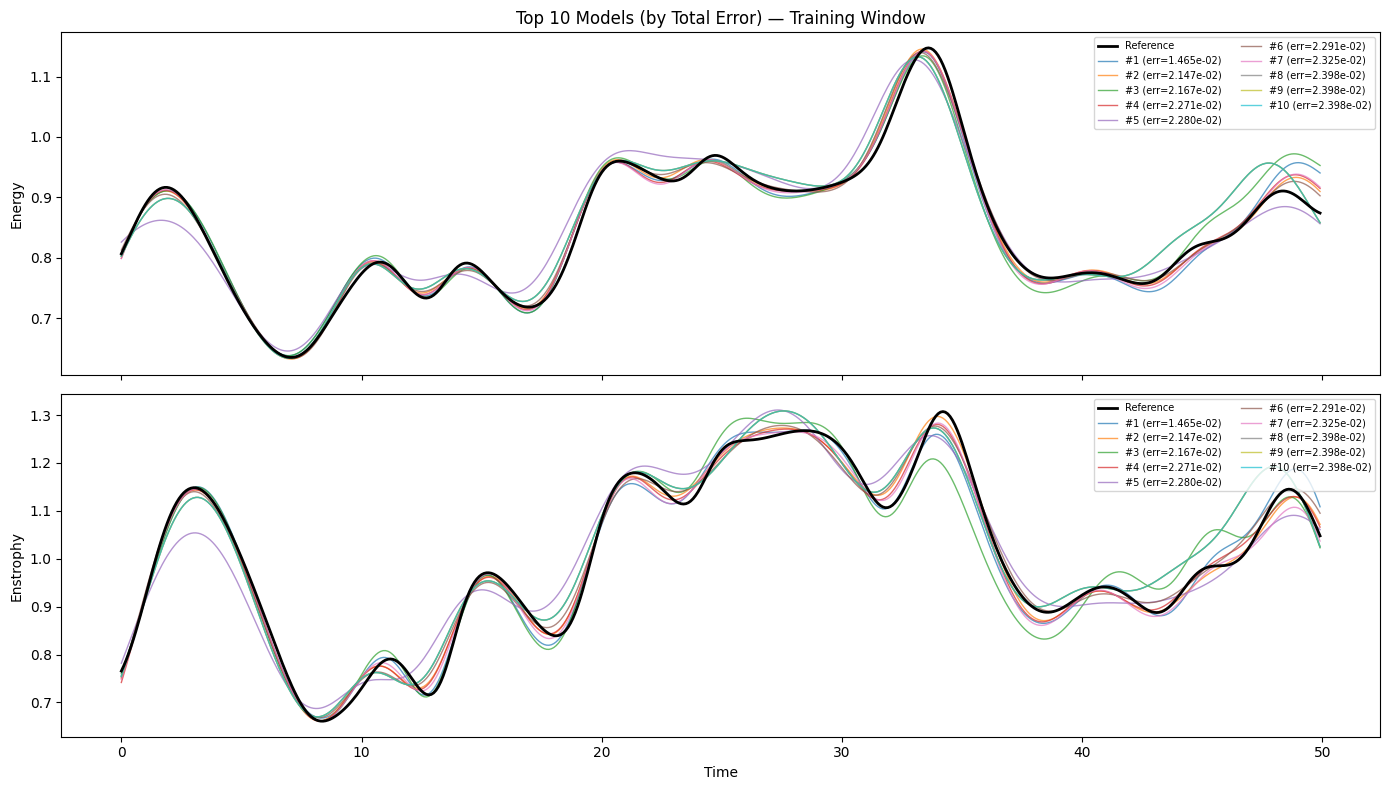

In [14]:
dt = 0.1
t_train = np.arange(N_TRAIN) * dt

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(t_train, ref_energy_train, "k-", lw=2, label="Reference", zorder=10)
axes[1].plot(t_train, ref_enstrophy_train, "k-", lw=2, label="Reference", zorder=10)

cmap = plt.cm.tab10

for i, res in enumerate(top10["total_error"]):
    A, F = res["A"], res["F"]
    C, G, c_vec = res["C"], res["G"], res["c"]

    f_rom = lambda x, A=A, F=F: A @ x + F @ get_quadratic_terms(x)
    is_nan, Xhat_pred = solve_difference_model(train_IC, N_TRAIN, f_rom)
    if is_nan:
        continue

    X_OpInf = Xhat_pred.T
    Xhat_scaled = (X_OpInf - mean_Xhat) / scaling_Xhat
    Xhat_2 = get_quadratic_terms(Xhat_scaled)
    Y_pred = C @ Xhat_scaled.T + G @ Xhat_2.T + c_vec[:, np.newaxis]

    label_str = f"#{i+1} (err={res['total_error']:.3e})"
    axes[0].plot(t_train, Y_pred[0, :], color=cmap(i), alpha=0.7, lw=1, label=label_str)
    axes[1].plot(t_train, Y_pred[1, :], color=cmap(i), alpha=0.7, lw=1, label=label_str)

axes[0].set_ylabel("Energy")
axes[0].set_title("Top 10 Models (by Total Error) — Training Window")
axes[0].legend(fontsize=7, ncol=2, loc="upper right")
axes[1].set_ylabel("Enstrophy")
axes[1].set_xlabel("Time")
axes[1].legend(fontsize=7, ncol=2, loc="upper right")
plt.tight_layout()
plt.show()

## 11. Test-Window Forecast — Top 10 by Total Error

Integrate from the **test IC** for `N_TEST` steps.

/home/anthonypoole/repos/not_work/IEEE/opinf/core.py:38: RuntimeWarning: overflow encountered in multiply
  prods = [X[i] * X[i:] for i in range(r)]
/tmp/ipykernel_5172/3479693249.py:11: RuntimeWarning: invalid value encountered in matmul
  f_rom = lambda x, A=A, F=F: A @ x + F @ get_quadratic_terms(x)


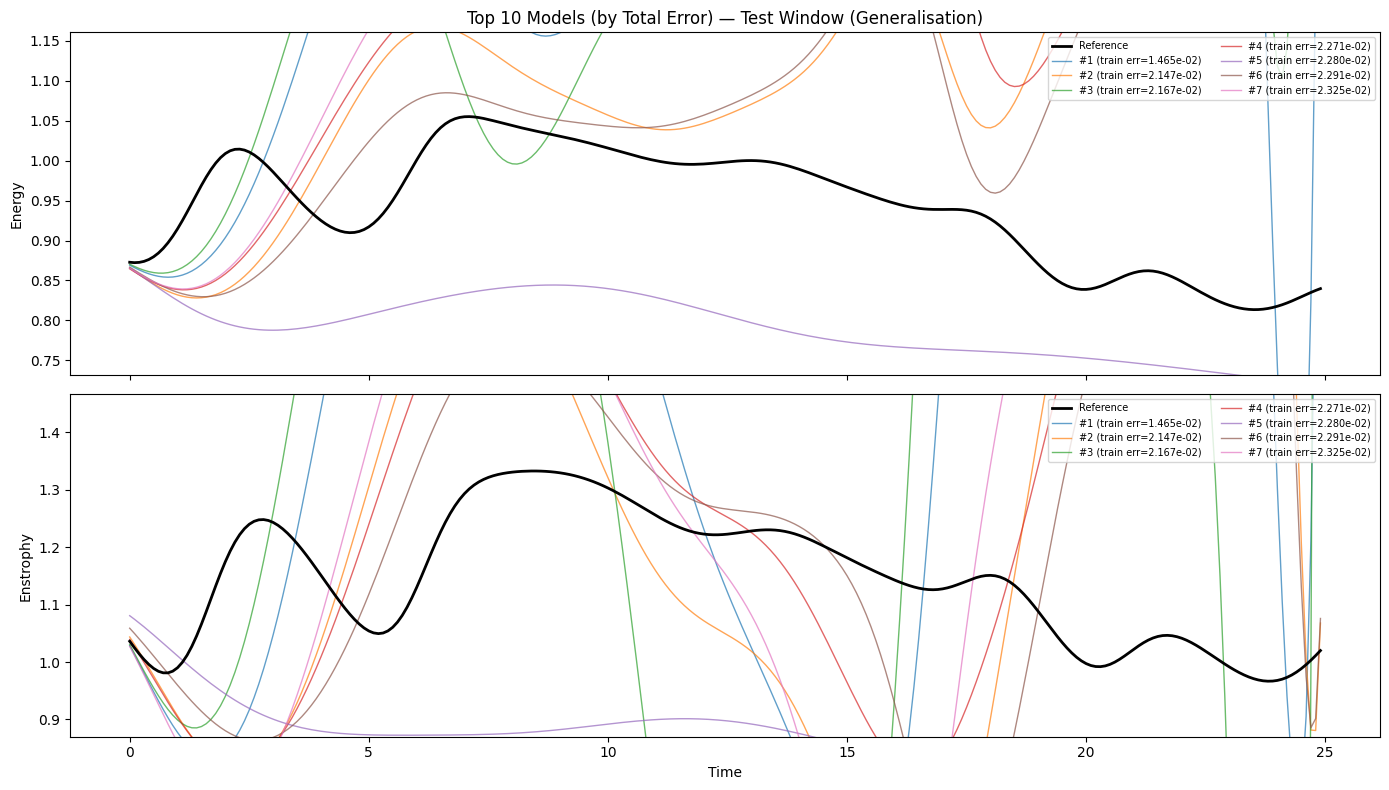

In [20]:
t_test = np.arange(N_TEST) * dt

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(t_test, ref_energy_test, "k-", lw=2, label="Reference", zorder=10)
axes[1].plot(t_test, ref_enstrophy_test, "k-", lw=2, label="Reference", zorder=10)

for i, res in enumerate(top10["total_error"]):
    A, F = res["A"], res["F"]
    C, G, c_vec = res["C"], res["G"], res["c"]

    f_rom = lambda x, A=A, F=F: A @ x + F @ get_quadratic_terms(x)
    is_nan, Xhat_pred = solve_difference_model(test_IC, N_TEST, f_rom)
    if is_nan:
        continue

    X_OpInf = Xhat_pred.T
    Xhat_scaled = (X_OpInf - mean_Xhat) / scaling_Xhat
    Xhat_2 = get_quadratic_terms(Xhat_scaled)
    Y_pred = C @ Xhat_scaled.T + G @ Xhat_2.T + c_vec[:, np.newaxis]

    label_str = f"#{i+1} (train err={res['total_error']:.3e})"
    axes[0].plot(t_test, Y_pred[0, :], color=cmap(i), alpha=0.7, lw=1, label=label_str)
    axes[1].plot(t_test, Y_pred[1, :], color=cmap(i), alpha=0.7, lw=1, label=label_str)

axes[0].set_ylabel("Energy")
axes[0].set_title("Top 10 Models (by Total Error) — Test Window (Generalisation)")
axes[0].legend(fontsize=7, ncol=2, loc="upper right")
axes[1].set_ylabel("Enstrophy")
axes[1].set_xlabel("Time")
axes[1].legend(fontsize=7, ncol=2, loc="upper right")
axes[0].set_ylim(ref_energy_test.min() * 0.9, ref_energy_test.max() * 1.1)
axes[1].set_ylim(ref_enstrophy_test.min() * 0.9, ref_enstrophy_test.max() * 1.1)
plt.tight_layout()
plt.show()

## 12. Scatter — Mean Error vs Std Error (Energy)

Each dot is one (state-reg, output-reg) combo. Colour = total error.

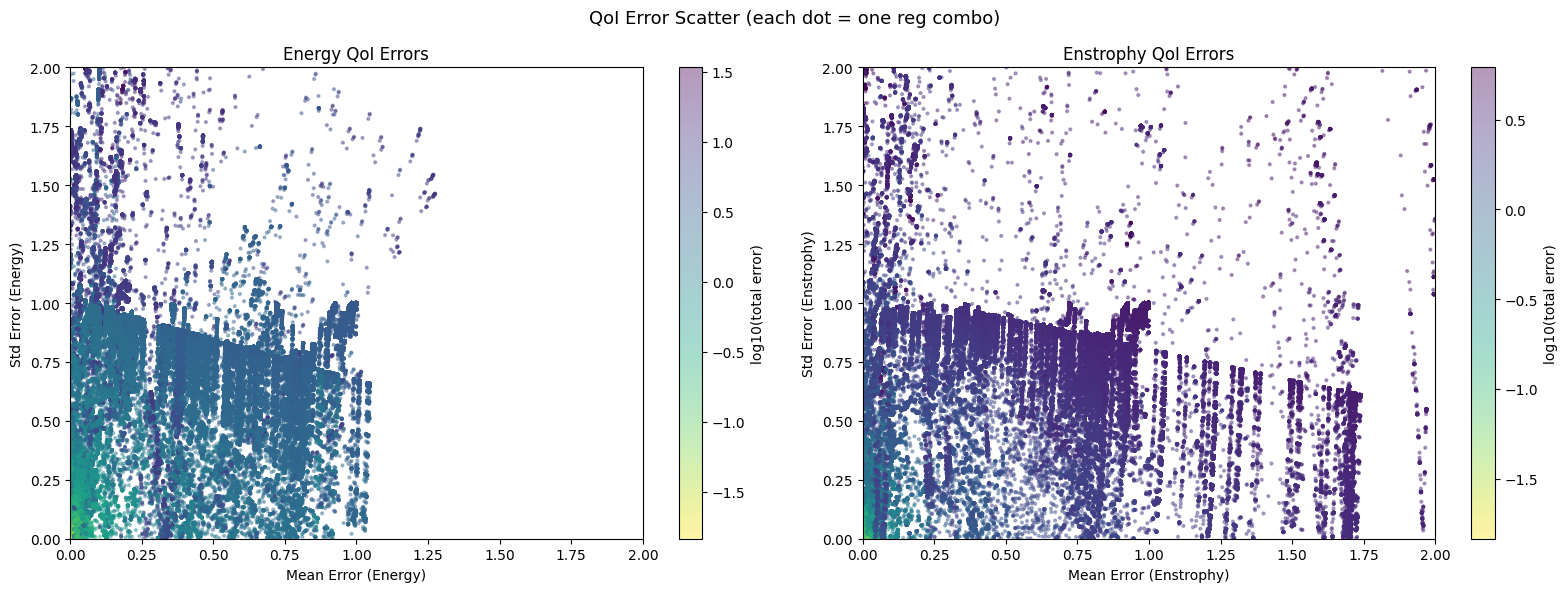

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Clip for visualisation
max_err = 2.0

# Energy
ax = axes[0]
mask = (mean_errs_energy < max_err) & (std_errs_energy < max_err)
sc = ax.scatter(
    mean_errs_energy[mask], std_errs_energy[mask],
    c=np.log10(np.clip(total_errors[mask], 1e-10, None)),
    s=4, alpha=0.4, cmap="viridis_r",
)
plt.colorbar(sc, ax=ax, label="log10(total error)")
ax.set_xlabel("Mean Error (Energy)")
ax.set_ylabel("Std Error (Energy)")
ax.set_title("Energy QoI Errors")
ax.set_xlim(0, max_err)
ax.set_ylim(0, max_err)

# Enstrophy
ax = axes[1]
mask = (mean_errs_enstr < max_err) & (std_errs_enstr < max_err)
sc = ax.scatter(
    mean_errs_enstr[mask], std_errs_enstr[mask],
    c=np.log10(np.clip(total_errors[mask], 1e-10, None)),
    s=4, alpha=0.4, cmap="viridis_r",
)
plt.colorbar(sc, ax=ax, label="log10(total error)")
ax.set_xlabel("Mean Error (Enstrophy)")
ax.set_ylabel("Std Error (Enstrophy)")
ax.set_title("Enstrophy QoI Errors")
ax.set_xlim(0, max_err)
ax.set_ylim(0, max_err)

plt.suptitle("QoI Error Scatter (each dot = one reg combo)", fontsize=13)
plt.tight_layout()
plt.show()

## 13. Forecast Plots — Top 10 by Mean Error (Energy)

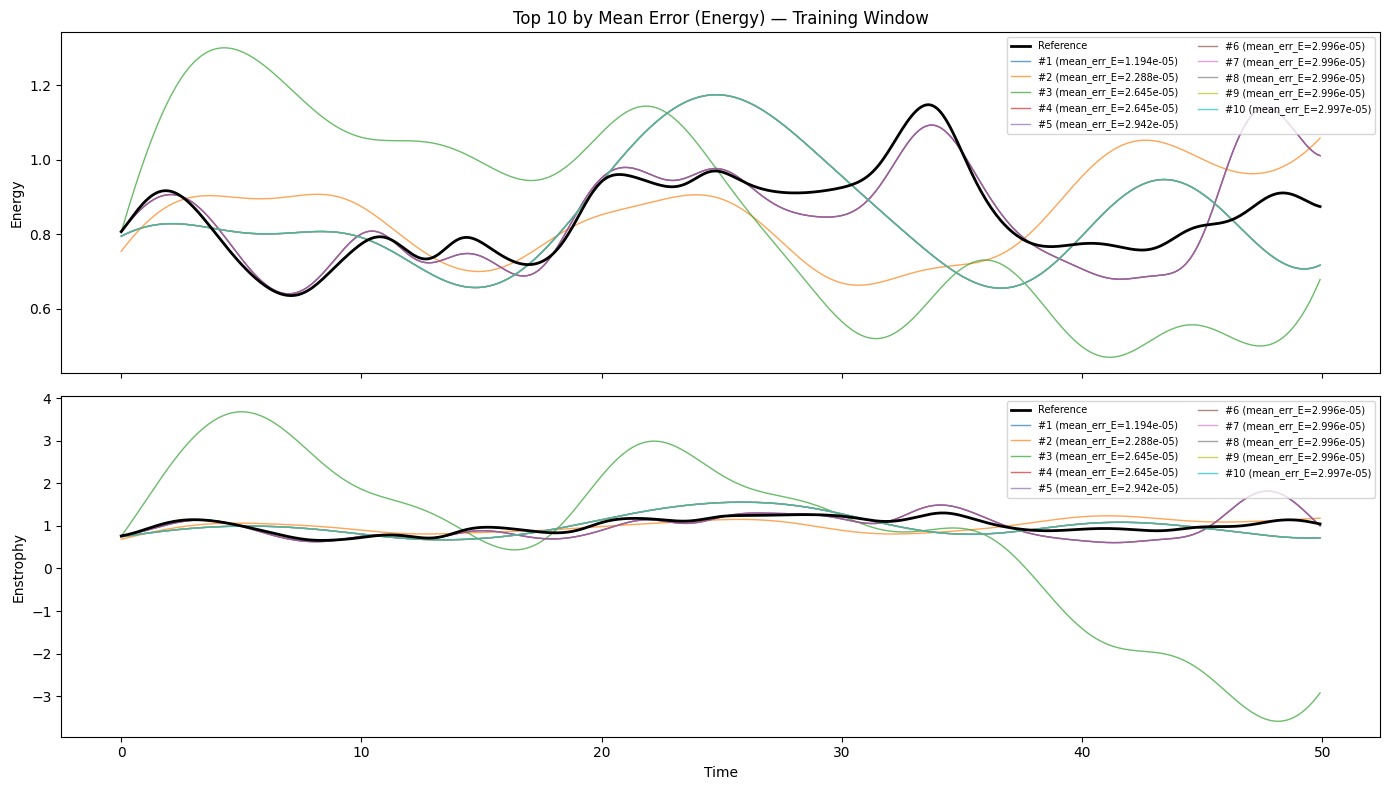

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(t_train, ref_energy_train, "k-", lw=2, label="Reference", zorder=10)
axes[1].plot(t_train, ref_enstrophy_train, "k-", lw=2, label="Reference", zorder=10)

for i, res in enumerate(top10["mean_err_energy"]):
    A, F = res["A"], res["F"]
    C, G, c_vec = res["C"], res["G"], res["c"]

    f_rom = lambda x, A=A, F=F: A @ x + F @ get_quadratic_terms(x)
    is_nan, Xhat_pred = solve_difference_model(train_IC, N_TRAIN, f_rom)
    if is_nan:
        continue

    X_OpInf = Xhat_pred.T
    Xhat_scaled = (X_OpInf - mean_Xhat) / scaling_Xhat
    Xhat_2 = get_quadratic_terms(Xhat_scaled)
    Y_pred = C @ Xhat_scaled.T + G @ Xhat_2.T + c_vec[:, np.newaxis]

    label_str = f"#{i+1} (mean_err_E={res['mean_err_energy']:.3e})"
    axes[0].plot(t_train, Y_pred[0, :], color=cmap(i), alpha=0.7, lw=1, label=label_str)
    axes[1].plot(t_train, Y_pred[1, :], color=cmap(i), alpha=0.7, lw=1, label=label_str)

axes[0].set_ylabel("Energy")
axes[0].set_title("Top 10 by Mean Error (Energy) — Training Window")
axes[0].legend(fontsize=7, ncol=2, loc="upper right")
axes[1].set_ylabel("Enstrophy")
axes[1].set_xlabel("Time")
axes[1].legend(fontsize=7, ncol=2, loc="upper right")
plt.tight_layout()
plt.show()

## 14. Forecast Plots — Top 10 by Std Error (Energy)

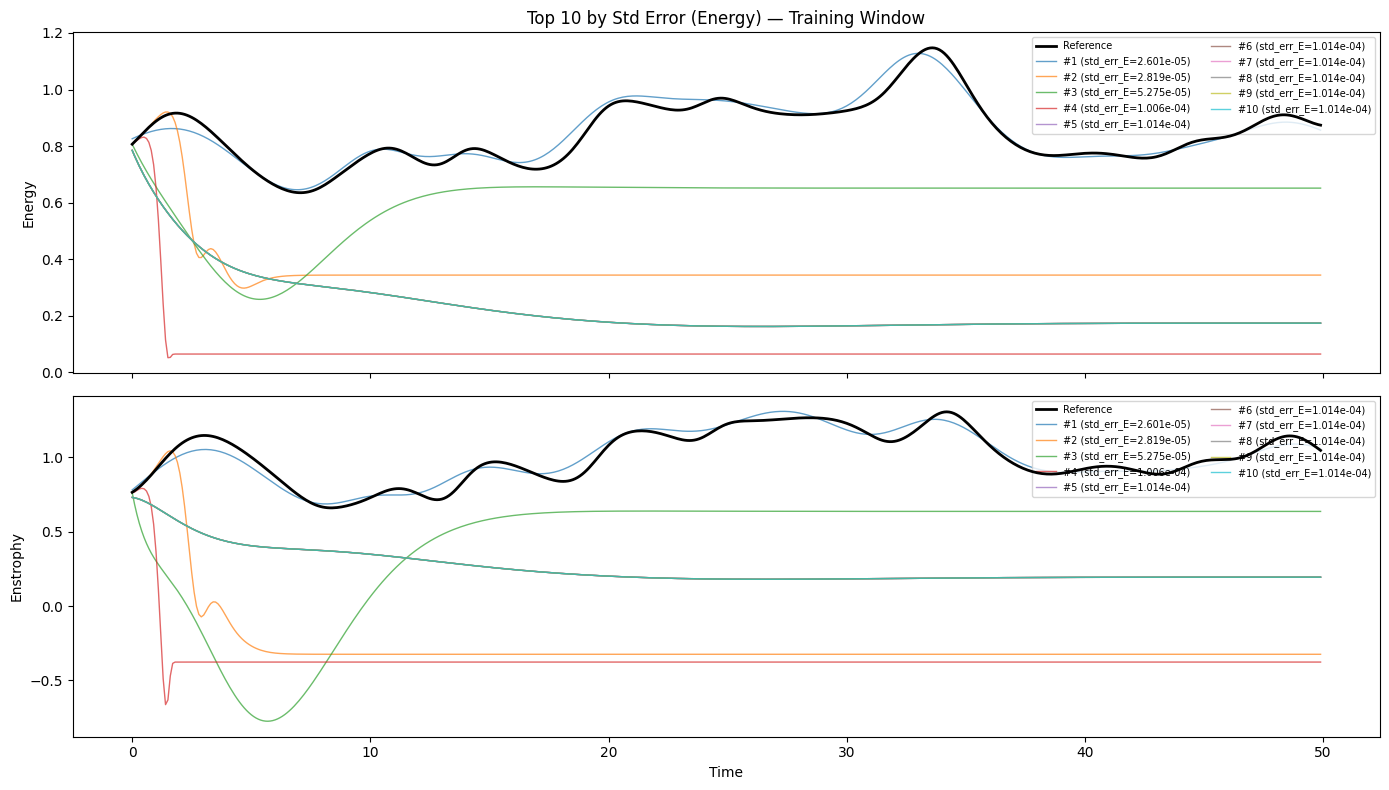

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(t_train, ref_energy_train, "k-", lw=2, label="Reference", zorder=10)
axes[1].plot(t_train, ref_enstrophy_train, "k-", lw=2, label="Reference", zorder=10)

for i, res in enumerate(top10["std_err_energy"]):
    A, F = res["A"], res["F"]
    C, G, c_vec = res["C"], res["G"], res["c"]

    f_rom = lambda x, A=A, F=F: A @ x + F @ get_quadratic_terms(x)
    is_nan, Xhat_pred = solve_difference_model(train_IC, N_TRAIN, f_rom)
    if is_nan:
        continue

    X_OpInf = Xhat_pred.T
    Xhat_scaled = (X_OpInf - mean_Xhat) / scaling_Xhat
    Xhat_2 = get_quadratic_terms(Xhat_scaled)
    Y_pred = C @ Xhat_scaled.T + G @ Xhat_2.T + c_vec[:, np.newaxis]

    label_str = f"#{i+1} (std_err_E={res['std_err_energy']:.3e})"
    axes[0].plot(t_train, Y_pred[0, :], color=cmap(i), alpha=0.7, lw=1, label=label_str)
    axes[1].plot(t_train, Y_pred[1, :], color=cmap(i), alpha=0.7, lw=1, label=label_str)

axes[0].set_ylabel("Energy")
axes[0].set_title("Top 10 by Std Error (Energy) — Training Window")
axes[0].legend(fontsize=7, ncol=2, loc="upper right")
axes[1].set_ylabel("Enstrophy")
axes[1].set_xlabel("Time")
axes[1].legend(fontsize=7, ncol=2, loc="upper right")
plt.tight_layout()
plt.show()

## 15. Summary Table of Best Models

In [19]:
print(f"{'='*100}")
print(f"  SUMMARY — TOP 10 BY TOTAL ERROR")
print(f"{'='*100}")
print(f"{'#':>3s}  {'total_err':>10s}  {'mean_E':>10s}  {'std_E':>10s}  "
      f"{'mean_Z':>10s}  {'std_Z':>10s}  {'state_err':>10s}  "
      f"{'asl':>10s}  {'asq':>10s}  {'aol':>10s}  {'aoq':>10s}")
print("-" * 100)

for i, res in enumerate(top10["total_error"]):
    print(f"{i+1:3d}  {res['total_error']:10.4e}  {res['mean_err_energy']:10.4e}  "
          f"{res['std_err_energy']:10.4e}  {res['mean_err_enstrophy']:10.4e}  "
          f"{res['std_err_enstrophy']:10.4e}  {res['rel_state_err']:10.4e}  "
          f"{res['asl']:10.2e}  {res['asq']:10.2e}  {res['aol']:10.2e}  {res['aoq']:10.2e}")

print(f"\n{'='*100}")
print(f"  SUGGESTED CONFIG VALUES")
print(f"{'='*100}")
best = top10["total_error"][0]
print(f"\nBest single model:")
print(f"  alpha_state_lin:  {best['asl']:.6e}")
print(f"  alpha_state_quad: {best['asq']:.6e}")
print(f"  alpha_out_lin:    {best['aol']:.6e}")
print(f"  alpha_out_quad:   {best['aoq']:.6e}")

# Suggest narrowed reg ranges based on top 10
asls = [r['asl'] for r in top10['total_error']]
asqs = [r['asq'] for r in top10['total_error']]
aols = [r['aol'] for r in top10['total_error']]
aoqs = [r['aoq'] for r in top10['total_error']]

print(f"\nSuggested narrowed ranges (covering top 10):")
print(f"  state_lin:  [{min(asls):.2e}, {max(asls):.2e}]")
print(f"  state_quad: [{min(asqs):.2e}, {max(asqs):.2e}]")
print(f"  out_lin:    [{min(aols):.2e}, {max(aols):.2e}]")
print(f"  out_quad:   [{min(aoqs):.2e}, {max(aoqs):.2e}]")

# Suggest threshold based on the 10th-best model
worst_top10 = top10["total_error"][9]
print(f"\nSuggested thresholds (to keep at least 10 models):")
print(f"  threshold_mean: {max(worst_top10['mean_err_energy'], worst_top10['mean_err_enstrophy']) * 1.1:.4f}")
print(f"  threshold_std:  {max(worst_top10['std_err_energy'], worst_top10['std_err_enstrophy']) * 1.1:.4f}")

  SUMMARY — TOP 10 BY TOTAL ERROR
  #   total_err      mean_E       std_E      mean_Z       std_Z   state_err         asl         asq         aol         aoq
----------------------------------------------------------------------------------------------------
  1  1.4647e-02  9.8071e-04  1.0782e-02  2.7106e-03  1.7303e-04  7.0095e-02    9.24e-02    1.27e+03    7.88e-04    1.61e-04
  2  2.1472e-02  1.8721e-03  1.4986e-02  1.2670e-03  3.3474e-03  7.0095e-02    9.24e-02    1.27e+03    1.89e-02    1.89e-02
  3  2.1665e-02  4.4117e-03  1.1399e-02  3.3016e-03  2.5531e-03  7.0095e-02    9.24e-02    1.27e+03    1.61e-04    6.72e-06
  4  2.2711e-02  7.3698e-04  8.5861e-03  2.8533e-03  1.0535e-02  7.0095e-02    9.24e-02    1.27e+03    9.24e-02    1.89e-02
  5  2.2805e-02  4.9737e-03  2.6009e-05  5.2740e-04  1.7278e-02  9.5071e-02    2.21e+00    3.04e+04    1.89e-02    4.52e-01
  6  2.2911e-02  2.0663e-03  3.9432e-03  1.8815e-03  1.5020e-02  7.0095e-02    9.24e-02    1.27e+03    9.24e-02    9.24e-